In [1]:
import time
from sympleq.models.random_hamiltonian import random_gate_symmetric_hamiltonian
from sympleq.core.circuits import SWAP, Hadamard, SUM, PHASE
from sympleq.core.symmetries.clifford import find_clifford_symmetries, qudit_cost, min_qudit_clifford_symmetry
from sympleq.core.circuits import Circuit
import numpy as np

In [6]:
n_tests = 5
p = 2
n_qudits_list = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]  # , 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300

times = []

for n_qudits in n_qudits_list:
    t_each_run = []
    n_paulis = n_qudits * 3 + 10
        
    for _ in range(n_tests):
        
        sym = SWAP(0, 1, p)
        # unscrambled H
        H = random_gate_symmetric_hamiltonian(sym, n_qudits, n_paulis, scrambled=False)
        C = Circuit.from_random(1000, H.dimensions).composite_gate()  # scrambling circuit
        H = C.act(H)
        H.weight_to_phase()
        scrambled_sym = Circuit(H.dimensions, [C.inv(), sym, C]).composite_gate()
        assert H.to_standard_form() == scrambled_sym.act(H).to_standard_form(
        ), f"\n{H.to_standard_form().__str__()}\n{sym.act(H).to_standard_form().__str__()}"

        known_F = scrambled_sym.symplectic

        start = time.time()
        symmetries = find_clifford_symmetries(H)
        end = time.time()
        
        assert len(symmetries) != 0

        for c in symmetries:
            # print(np.all(c.symplectic == known_F) and np.all(
            #     c.phase_vector == scrambled_sym.phase_vector))
            H_s = H.to_standard_form()
            H_out = c.act(H).to_standard_form()
            H_s.weight_to_phase()
            H_out.weight_to_phase()
            assert np.all(H_s.tableau == H_out.tableau)
            assert np.all(H_s.phases == H_out.phases)
            assert np.all(H_s.weights == H_out.weights)
            assert c.act(H).to_standard_form() == H.to_standard_form()
        print('done n_qudits=', n_qudits, ' run number ', _, 'time=', time.time() - start)
        
        t_each_run.append(end - start)
    times.append(t_each_run)

mean_times = [np.mean(t) for t in times]
median_times = [np.median(t) for t in times]
times_max = [np.max(t) for t in times]
times_min = [np.min(t) for t in times]
variances = [np.var(t) for t in times]

done n_qudits= 10  run number  0 time= 0.05418038368225098
done n_qudits= 10  run number  1 time= 0.05165457725524902
done n_qudits= 10  run number  2 time= 0.052651166915893555
done n_qudits= 10  run number  3 time= 0.0518498420715332
done n_qudits= 10  run number  4 time= 0.053797006607055664
done n_qudits= 20  run number  0 time= 0.16701388359069824
done n_qudits= 20  run number  1 time= 0.17007160186767578
done n_qudits= 20  run number  2 time= 0.17212557792663574
done n_qudits= 20  run number  3 time= 0.16771888732910156
done n_qudits= 20  run number  4 time= 0.17246317863464355
done n_qudits= 30  run number  0 time= 0.3510406017303467
done n_qudits= 30  run number  1 time= 0.357135534286499
done n_qudits= 30  run number  2 time= 0.35244107246398926
done n_qudits= 30  run number  3 time= 0.1810145378112793
done n_qudits= 30  run number  4 time= 0.18911194801330566
done n_qudits= 40  run number  0 time= 0.3198552131652832
done n_qudits= 40  run number  1 time= 0.30650877952575684
d

Text(0, 0.5, 'Time to find SWAP symmetry (s)')

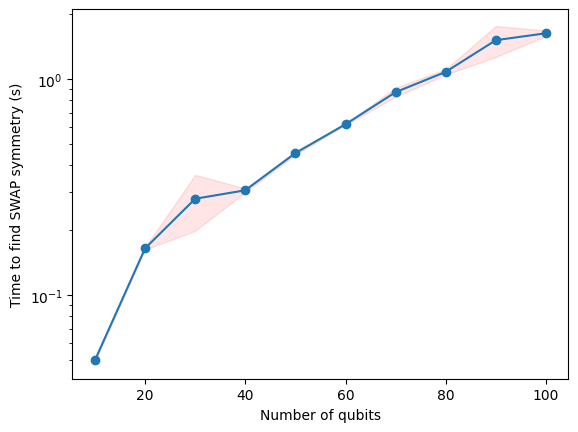

In [7]:
# plot times and variances
import matplotlib.pyplot as plt
plt.semilogy(n_qudits_list, mean_times, marker='o')
# plt.semilogy(n_qudits_list, median_times, marker='x', label='Median')
# fill in area between max and min
# plt.fill_between(n_qudits_list, times_max, times_min, alpha=0.2)
# standard deviation of each n_q
std_dev = np.asarray([np.std(times[i]) for i in range(len(n_qudits_list))])
plt.fill_between(n_qudits_list, mean_times - std_dev, mean_times + std_dev, alpha=0.1, color='red', label='Std Dev')
# plt.legend()
# plt.plot(n_qs, times_max, marker='^', label='Max')
# plt.plot(n_qs, times_min, marker='d', label='Min')
plt.xlabel('Number of qubits')
plt.ylabel('Time to find SWAP symmetry (s)')

In [7]:
np.savez('scripts/personal/Data/swap_symmetry_times.npz', n_qudits=n_qudits_list, mean_times=mean_times, median_times=median_times, times_max=times_max, times_min=times_min, variances=variances)

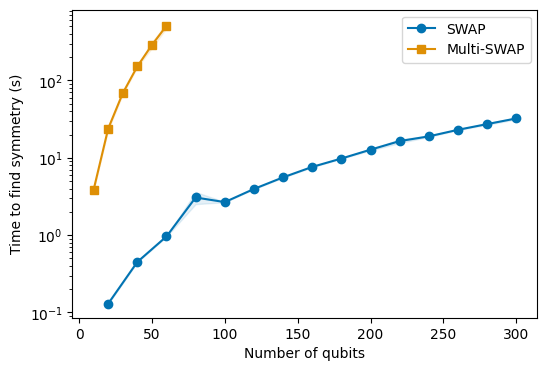

In [8]:
data = np.load('scripts/personal/Data/swap_symmetry_times.npz')

n_qudits = data['n_qudits']
mean_times = data['mean_times']
median_times = data['median_times']
times_max = data['times_max']
times_min = data['times_min']
variances = data['variances']

data2 = np.load('scripts/personal/Data/Mulit_swap_symmetry_times.npz')

n_qudits2 = data2['n_qudits']
mean_times2 = data2['mean_times']
median_times2 = data2['median_times']
times_max2 = data2['times_max']
times_min2 = data2['times_min']
variances2 = data2['variances']

# plot
import matplotlib.pyplot as plt
import seaborn as sns

cols = sns.color_palette('colorblind')

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.semilogy(n_qudits, mean_times, c=cols[0], marker='o', label='SWAP')
ax.semilogy(n_qudits2, mean_times2, c=cols[1], marker='s', label='Multi-SWAP')
# plt.semilogy(n_qudits, median_times, marker='x', label='Median')
# fill in area between max and min
# plt.fill_between(n_qudits, times_max, times_min, alpha=0.2)
# standard deviation of each n_q
std_dev = variances
ax.fill_between(n_qudits, mean_times - std_dev, mean_times + std_dev, alpha=0.1, color=cols[0])
ax.fill_between(n_qudits2, mean_times2 - variances2, mean_times2 + variances2, alpha=0.1, color=cols[1])
# plt.legend()
# plt.plot(n_qs, times_max, marker='^', label='Max')
# plt.plot(n_qs, times_min, marker='d', label='Min')
ax.set_xlabel('Number of qubits')
ax.set_ylabel('Time to find symmetry (s)')
ax.legend()

fig.savefig('scripts/personal/Data/swap_symmetry_times.png', dpi=300)


In [4]:
# multiswap finder

n_tests = 100
p = 2
n_qudits_list = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300] 

times = []

for n_qudits in n_qudits_list:
    t_each_run = []
    n_paulis = n_qudits * 3 + 10
    dims = [p] * n_qudits
    for _ in range(n_tests):
        
        sym = Circuit(dims, [SWAP(0, 1, p), SWAP(1, 2, p), SWAP(2, 3, p)]).composite_gate()
        # unscrambled H
        H = random_gate_symmetric_hamiltonian(sym, n_qudits, n_paulis, scrambled=False)
        C = Circuit.from_random(1000, H.dimensions).composite_gate()  # scrambling circuit
        H = C.act(H)
        H.weight_to_phase()
        scrambled_sym = Circuit(H.dimensions, [C.inv(), sym, C]).composite_gate()
        # assert H.to_standard_form() == scrambled_sym.act(H).to_standard_form(
        # ), f"\n{H.to_standard_form().__str__()}\n{sym.act(H).to_standard_form().__str__()}"

        known_F = scrambled_sym.symplectic

        start = time.time()
        symmetries = find_clifford_symmetries(H)
        end = time.time()
        assert len(symmetries) != 0

        # for c in symmetries:
        #     # print(np.all(c.symplectic == known_F) and np.all(
        #     #     c.phase_vector == scrambled_sym.phase_vector))
        #     H_s = H.to_standard_form()
        #     H_out = c.act(H).to_standard_form()
        #     H_s.weight_to_phase()
        #     H_out.weight_to_phase()
        #     assert np.all(H_s.tableau == H_out.tableau)
        #     assert np.all(H_s.phases == H_out.phases)
        #     assert np.all(H_s.weights == H_out.weights)
        #     assert c.act(H).to_standard_form() == H.to_standard_form()
        print('done n_qudits=', n_qudits, ' run number ', _, 'time=', time.time() - start)
        
        t_each_run.append(end - start)
    times.append(t_each_run)

mean_times = [np.mean(t) for t in times]
median_times = [np.median(t) for t in times]
times_max = [np.max(t) for t in times]
times_min = [np.min(t) for t in times]
variances = [np.var(t) for t in times]

np.savez('scripts/personal/Data/Multi_swap_symmetry_times.npz', n_qudits=n_qudits_list, mean_times=mean_times, median_times=median_times, times_max=times_max, times_min=times_min, variances=variances)

done n_qudits= 20  run number  0 time= 0.9748156070709229
done n_qudits= 20  run number  1 time= 0.10209155082702637
done n_qudits= 20  run number  2 time= 0.10350728034973145
done n_qudits= 20  run number  3 time= 0.09979796409606934
done n_qudits= 20  run number  4 time= 0.09632682800292969
done n_qudits= 20  run number  5 time= 0.09788203239440918
done n_qudits= 20  run number  6 time= 0.1009824275970459
done n_qudits= 20  run number  7 time= 0.09134340286254883
done n_qudits= 20  run number  8 time= 0.1009213924407959
done n_qudits= 20  run number  9 time= 0.09911537170410156
done n_qudits= 20  run number  10 time= 0.09478473663330078
done n_qudits= 20  run number  11 time= 0.09262204170227051
done n_qudits= 20  run number  12 time= 0.09781622886657715
done n_qudits= 20  run number  13 time= 0.09774971008300781
done n_qudits= 20  run number  14 time= 0.10024023056030273
done n_qudits= 20  run number  15 time= 0.11573338508605957
done n_qudits= 20  run number  16 time= 0.09426879882

KeyboardInterrupt: 

Text(0, 0.5, 'Time to find symmetry (s)')

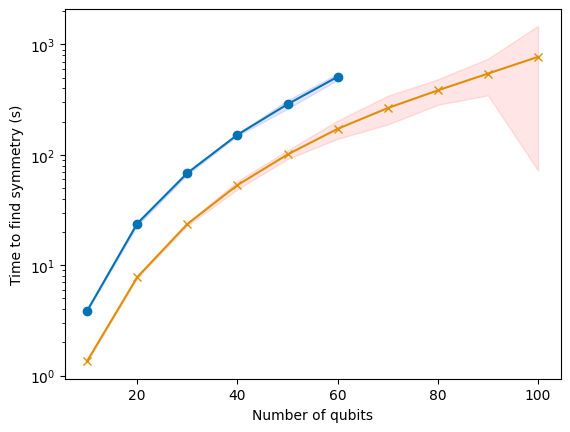

In [11]:
# plot times and variances
import matplotlib.pyplot as plt
import seaborn as sns

cols = sns.color_palette('colorblind')

data_swap = np.load('scripts/personal/Data/swap_symmetry_times.npz')

n_qudits_list_swap = data_swap['n_qudits']
mean_times_swap = data_swap['mean_times']
median_times_swap = data_swap['median_times']
times_max_swap = data_swap['times_max']
times_min_swap = data_swap['times_min']
variances_swap = data_swap['variances']

data_multi_swap = np.load('scripts/personal/Data/Mulit_swap_symmetry_times.npz')

n_qudits_list_multi_swap = data_multi_swap['n_qudits']
mean_times_multi_swap = data_multi_swap['mean_times']    
median_times_multi_swap = data_multi_swap['median_times']
times_max_multi_swap = data_multi_swap['times_max']
times_min_multi_swap = data_multi_swap['times_min']
variances_multi_swap = data_multi_swap['variances']

plt.semilogy(n_qudits_list_multi_swap, mean_times_multi_swap, marker='o', color=cols[0])
plt.semilogy(n_qudits_list_swap, mean_times_swap, marker='x', color=cols[1])
# plt.semilogy(n_qudits_list, median_times, marker='x', label='Median')
# fill in area between max and min
# plt.fill_between(n_qudits_list, times_max, times_min, alpha=0.2)
# standard deviation of each n_q
std_dev = np.asarray([np.std(times[i]) for i in range(len(n_qudits_list))])
plt.fill_between(n_qudits_list_swap, mean_times_swap - variances_swap, mean_times_swap + variances_swap,
 alpha=0.1, color='red')
plt.fill_between(n_qudits_list_multi_swap, mean_times_multi_swap - variances_multi_swap, mean_times_multi_swap + variances_multi_swap,
alpha=0.1, color='blue')
# plt.legend()
# plt.plot(n_qs, times_max, marker='^', label='Max')
# plt.plot(n_qs, times_min, marker='d', label='Min')
plt.xlabel('Number of qubits')
plt.ylabel('Time to find symmetry (s)')


In [4]:
# complex symmetry finder

n_tests = 10
p = 2
n_qudits_list = [10, 20, 30, 40]  # , 40, 50, 60, 70, 80, 90, 100

times = []

for n_qudits in n_qudits_list:
    t_each_run = []
    n_paulis = n_qudits * 3 + 10
    dims = [p] * n_qudits
    for _ in range(n_tests):
        
        sym = Circuit.from_random(depth=10, dimensions=dims).composite_gate()
        # unscrambled H
        H = random_gate_symmetric_hamiltonian(sym, n_qudits, n_paulis, scrambled=False)
        C = Circuit.from_random(1000, H.dimensions).composite_gate()  # scrambling circuit
        H = C.act(H)
        H.weight_to_phase()
        scrambled_sym = Circuit(H.dimensions, [C.inv(), sym, C]).composite_gate()

        # print(H.to_standard_form()[1])
        # print(scrambled_sym.act(H).to_standard_form()[1])


        assert np.all(H.to_standard_form() == scrambled_sym.act(H).to_standard_form()
        ), f"\n{H.to_standard_form().tableau}\n\n\n{sym.act(H).to_standard_form().tableau}"
        # f"\n{H.to_standard_form().__str__()}\n\n\n{sym.act(H).to_standard_form().__str__()}"

        known_F = scrambled_sym.symplectic
        if np.array_equal(known_F, np.eye(known_F.shape[0], dtype=known_F.dtype)) or H.n_paulis() <= 2 * n_qudits:
            # trivial symmetry, skip
            print("Trivial symmetry" if H.n_paulis() <= 2 * n_qudits else "n_paulis too small")
            continue
        start = time.time()
        # symmetries = find_clifford_symmetries(H)
        F, S, T = min_qudit_clifford_symmetry(H)

        assert qudit_cost(S) <= qudit_cost(sym), f"Expected cost {qudit_cost(sym)}, got {qudit_cost(S)} \n {F.symplectic}"
        print("Qudit cost ", qudit_cost(S))
        print("Max expected qudit cost", qudit_cost(sym))

        print('done n_qudits=', n_qudits, ' run number ', _, 'time=', time.time() - start)
        end = time.time()
        t_each_run.append(end - start)
    times.append(t_each_run)

mean_times = [np.mean(t) for t in times]
median_times = [np.median(t) for t in times]
times_max = [np.max(t) for t in times]
times_min = [np.min(t) for t in times]
variances = [np.var(t) for t in times]


Trivial symmetry
Got symmetry - decomposing
Qudit cost  2
Max expected qudit cost 2
done n_qudits= 10  run number  1 time= 0.08714938163757324
Trivial symmetry
Got symmetry - decomposing


AssertionError: Expected cost 2, got 4 
 [[0 0 1 1 0 0 1 1 1 1 1 1 0 1 1 0 1 0 1 0]
 [0 1 0 0 1 1 1 0 0 0 1 0 0 0 1 1 0 1 0 0]
 [1 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 1 1 0 1]
 [1 0 0 1 0 1 1 1 0 1 0 0 1 1 1 0 0 1 0 0]
 [0 0 0 1 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 1]
 [1 1 1 1 1 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1]
 [1 0 1 0 0 0 0 1 0 0 1 1 0 1 0 0 1 1 0 0]
 [1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 1 0 0]
 [1 0 0 1 1 1 0 1 0 1 0 1 0 1 1 1 1 1 1 1]
 [1 1 0 1 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 1]
 [1 0 1 0 1 1 1 1 1 1 0 0 1 0 0 0 1 0 0 0]
 [1 0 0 1 1 1 1 1 1 1 0 1 0 1 0 1 0 0 1 1]
 [0 1 0 0 0 1 1 0 1 1 0 0 0 1 1 0 0 0 1 1]
 [0 1 1 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1]
 [1 0 1 0 0 1 0 1 1 1 1 0 0 0 1 1 1 1 0 0]
 [0 1 1 0 1 0 0 1 1 0 1 0 0 1 1 1 0 1 0 1]
 [1 0 0 0 0 0 1 0 1 1 1 0 0 1 0 0 1 0 0 1]
 [0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 0 0 1 0]
 [0 1 0 0 1 0 1 0 1 1 1 1 0 0 1 1 0 1 1 0]]

In [18]:
import time
import traceback
import multiprocessing as mp

class _TimeoutError(Exception):
    pass


def _search_symmetry(q, H):
    try:
        # F, S, T = min_qudit_clifford_symmetry(H)
        F = find_clifford_symmetries(H)
        q.put({"ok": True, "F": F})
    except Exception as e:
        q.put({"ok": False, "error": repr(e), "traceback": traceback.format_exc()})


def _run_one_case(q, i, n_qudits, n_paulis, dims, circuit_depth=10, scramble_depth=1000, search_timeout=30):
    """Runs a single iteration. Only the symmetry search is time-limited."""
    t0 = time.time()
    try:
        sym = Circuit.from_random(depth=circuit_depth, dimensions=dims).composite_gate()

        H = random_gate_symmetric_hamiltonian(sym, n_qudits, n_paulis, scrambled=False)
        C = Circuit.from_random(scramble_depth, H.dimensions).composite_gate()
        H = C.act(H)
        H.weight_to_phase()
        scrambled_sym = Circuit(H.dimensions, [C.inv(), sym, C]).composite_gate()

        exp_cost = qudit_cost(sym)
        assert np.all(H.to_standard_form() == scrambled_sym.act(H).to_standard_form()), f"\n{H.to_standard_form().tableau}\n\n{sym.act(H).to_standard_form().tableau}"

        # Time-limit the heavy symmetry search in its own process
        q_search = mp.Queue()
        p_search = mp.Process(target=_search_symmetry, args=(q_search, H))
        p_search.start()
        p_search.join(search_timeout)

        if p_search.is_alive():
            p_search.terminate()
            p_search.join()
            raise _TimeoutError()

        if q_search.empty():
            raise RuntimeError("search produced no result")

        search_res = q_search.get()
        if not search_res["ok"]:
            raise RuntimeError(search_res["error"])

        # S = search_res["S"]
        # got_cost = qudit_cost(S)

        q.put({
            "ok": True,
            "i": i,
            "expected_cost": exp_cost,
            # "got_cost": got_cost,
            "time": time.time() - t0,
        })
    except _TimeoutError:
        q.put({
            "ok": False,
            "i": i,
            "time": time.time() - t0,
            "error": "search timeout",
            "traceback": "find_clifford_symmetries timed out",
        })
    except Exception as e:
        q.put({
            "ok": False,
            "i": i,
            "time": time.time() - t0,
            "error": repr(e),
            "traceback": traceback.format_exc(),
        })


def run_tests(n_tests, n_qudits, n_paulis, dims, t_each_run, search_timeout=30, circuit_depth=10, scramble_depth=1000):
    for i in range(n_tests):
        q = mp.Queue()
        p = mp.Process(target=_run_one_case, args=(q, i, n_qudits, n_paulis, dims), kwargs={"search_timeout": search_timeout, "circuit_depth": circuit_depth, "scramble_depth": scramble_depth})
        p.start()
        p.join()

        if q.empty():
            print(f"[{i}] finished but produced no result -> skipping")
            continue

        res = q.get()

        if not res["ok"]:
            print(f"[{i}] failed: {res['error']}")
            print(res['traceback'])
            continue

        # print(f"[{i}] Max expected qudit cost {res['expected_cost']}")
        # print(f"[{i}] Qudit cost {res['got_cost']}")    
        print(f"[{i}] done n_qudits={n_qudits} time={res['time']:.3f}s")
        t_each_run.append(res["time"])


# complex symmetry finder

n_tests = 5
p = 2
n_qudits_list = [10, 15, 20, 22, 24, 26]
circuit_depth = 10

times = []

for n_qudits in n_qudits_list:
    t_each_run = []
    n_paulis = n_qudits * 3 + 10
    dims = [p] * n_qudits
    run_tests(
        n_tests=n_tests,
        n_qudits=n_qudits,
        n_paulis=n_paulis,
        dims=dims,
        t_each_run=t_each_run,
        search_timeout=300,
    )
    times.append(t_each_run)

mean_times = [np.mean(t) if len(t)>0 else float('nan') for t in times]
median_times = [np.median(t) if len(t)>0 else float('nan') for t in times]
times_max = [np.max(t) if len(t)>0 else float('nan') for t in times]
times_min = [np.min(t) if len(t)>0 else float('nan') for t in times]
variances = [np.var(t) if len(t)>0 else float('nan') for t in times]

np.savez(f'scripts/personal/Data/complex_symmetry_times_{circuit_depth}_avgs={n_tests}.npz',
         n_qudits=n_qudits_list,
         mean_times=mean_times,
         median_times=median_times,
         times_max=times_max,
         times_min=times_min,
         variances=variances)


[0] done n_qudits=10 time=1.041s
[1] done n_qudits=10 time=1.269s
[2] done n_qudits=10 time=0.999s
[3] done n_qudits=10 time=1.015s
[4] done n_qudits=10 time=0.960s
[0] done n_qudits=15 time=1.060s
[1] done n_qudits=15 time=1.092s
[2] done n_qudits=15 time=1.035s
[3] done n_qudits=15 time=1.000s
[4] done n_qudits=15 time=1.061s
[0] done n_qudits=20 time=1.077s
[1] done n_qudits=20 time=1.147s
[2] done n_qudits=20 time=1.076s
[3] done n_qudits=20 time=1.077s
[4] done n_qudits=20 time=1.182s
[0] done n_qudits=22 time=1.188s
[1] done n_qudits=22 time=1.166s
[2] done n_qudits=22 time=1.080s
[3] done n_qudits=22 time=1.098s
[4] done n_qudits=22 time=1.072s
[0] done n_qudits=24 time=1.094s
[1] done n_qudits=24 time=1.114s
[2] done n_qudits=24 time=1.139s
[3] done n_qudits=24 time=1.206s
[4] done n_qudits=24 time=1.283s
[0] failed: search timeout
find_clifford_symmetries timed out
[1] failed: search timeout
find_clifford_symmetries timed out
[2] failed: search timeout
find_clifford_symmetries

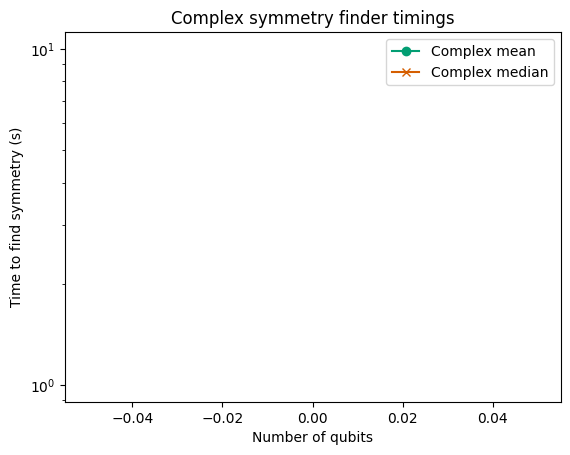

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cols = sns.color_palette('colorblind')

data_complex = np.load(f'scripts/personal/Data/complex_symmetry_times_{circuit_depth}_avgs={n_tests}.npz')

n_qudits_list_complex = data_complex['n_qudits']
mean_times_complex = data_complex['mean_times']
median_times_complex = data_complex['median_times']
times_max_complex = data_complex['times_max']
times_min_complex = data_complex['times_min']
variances_complex = data_complex['variances']

plt.semilogy(n_qudits_list_complex, mean_times_complex, marker='o', color=cols[2], label='Complex mean')
plt.semilogy(n_qudits_list_complex, median_times_complex, marker='x', color=cols[3], label='Complex median')
plt.fill_between(n_qudits_list_complex,
                 mean_times_complex - np.sqrt(variances_complex),
                 mean_times_complex + np.sqrt(variances_complex),
                 alpha=0.1, color=cols[2])
plt.xlabel('Number of qubits')
plt.ylabel('Time to find symmetry (s)')
plt.legend()
plt.title('Complex symmetry finder timings')
plt.show()
